# Module 4: Geospatial Emoji Sentiment Analysis (LSTMs)

In this notebook, we combine **Natural Language Processing (NLP)** with **Geospatial Context**. This is a powerful technique used by urban planners, disaster response teams, and brands to understand *what* people are saying and *where* they are saying it.

### The 5-Class Emoji Sentiment Scale
Instead of a simple "Good" vs. "Bad" binary, we will classify sentiment into a nuanced range of 5 emojis:
1.  😠 **Strongly Negative** (Class 0)
2.  😟 **Negative** (Class 1)
3.  😐 **Neutral** (Class 2)
4.  🙂 **Positive** (Class 3)
5.  😍 **Strongly Positive** (Class 4)

### Geospatial NLP Applications
- **Crisis Mapping:** Identifying regions where residents are reporting infrastructure damage during a storm.
- **Public Sentiment:** Tracking how sentiment towards a new city park varies across different neighborhoods.
- **Logistics:** Monitoring delivery satisfaction in specific geographic zones.

## 1. Data Preprocessing with Location

We will create a synthetic dataset that includes text (reviews/tweets), a sentiment label (0-4), and location data (Latitude and Longitude).

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# Emoji Mapping for visualization
sentiment_map = {
    0: "😠",
    1: "😟",
    2: "😐",
    3: "🙂",
    4: "😍"
}

# Sample Geospatial Dataset
# (Text, Sentiment Label, Lat, Lon, City)
raw_data = [
    ("The local park is absolutely disgusting and dangerous.", 0, 40.7128, -74.0060, "New York"),
    ("I really hate the traffic in this part of town, it's terrible.", 1, 40.7580, -73.9855, "New York"),
    ("Just walking through the city, fairly standard day.", 2, 40.7306, -73.9352, "New York"),
    ("Had a great coffee near the museum, very pleasant!", 3, 34.0522, -118.2437, "Los Angeles"),
    ("The weather here is perfect! I am so happy in this city!", 4, 34.0928, -118.3287, "Los Angeles"),
    ("Garbage everywhere, nobody cleans this street.", 0, 34.0407, -118.2688, "Los Angeles"),
    ("It's okay, but moving here was a mistake.", 1, 51.5074, -0.1278, "London"),
    ("The architecture is alright, nothing special.", 2, 51.5300, -0.1100, "London"),
    ("Wonderful afternoon at the gallery.", 4, 51.5033, -0.1195, "London")
]

# Vocabulary Building
def tokenize(text):
    return re.sub(r"[^a-zA-Z0-9\s]", "", text.lower()).split()

all_tokens = []
for text, label, lat, lon, city in raw_data: all_tokens.extend(tokenize(text))

vocab = {word: i+2 for i, (word, c) in enumerate(Counter(all_tokens).most_common())}
vocab["<PAD>"], vocab["<UNK>"] = 0, 1
inv_vocab = {i: word for word, i in vocab.items()}

print(f"Vocabulary Size: {len(vocab)}")

Vocabulary Size: 60


## 2. Multi-Class LSTM Dataset
We need to handle the integer labels (0-4) and pad the sequences.

In [7]:
MAX_LEN = 12

class GeoEmojiDataset(Dataset):
    def __init__(self, data, vocab, max_len):
        self.data = data
        self.vocab = vocab
        self.max_len = max_len
        
    def __len__(self): return len(self.data)
        
    def __getitem__(self, idx):
        text, label, lat, lon, city = self.data[idx]
        indices = [self.vocab.get(t, 1) for t in tokenize(text)][:self.max_len]
        indices += [0] * (self.max_len - len(indices))
        return torch.tensor(indices), torch.tensor(label, dtype=torch.long)

dataset = GeoEmojiDataset(raw_data, vocab, MAX_LEN)
loader = DataLoader(dataset, batch_size=3, shuffle=True)

sample_x, sample_y = next(iter(loader))
print(f"Target labels for sample batch: {sample_y.tolist()}")

Target labels for sample batch: [3, 1, 0]


## 3. Deep Learning Architecture
Our model now outputs **5 values** representing the scores for each sentiment emoji.

In [8]:
class GeoSentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes=5):
        super(GeoSentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        return self.fc(hidden[-1])

model = GeoSentimentLSTM(len(vocab), 32, 64)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("Model set for 5-class emoji classification.")

Model set for 5-class emoji classification.


## 4. Training the Model

In [9]:
epochs = 30
for epoch in range(epochs):
    for x, y in loader:
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")

Epoch 10/30 - Loss: 0.0802
Epoch 20/30 - Loss: 0.0046
Epoch 30/30 - Loss: 0.0016


## 5. Geospatial Visualization Dashboard
We will map our predictions onto a coordinate space to see regional sentiment trends.

d:\setups\ml-dl\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128578 (\N{SLIGHTLY SMILING FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


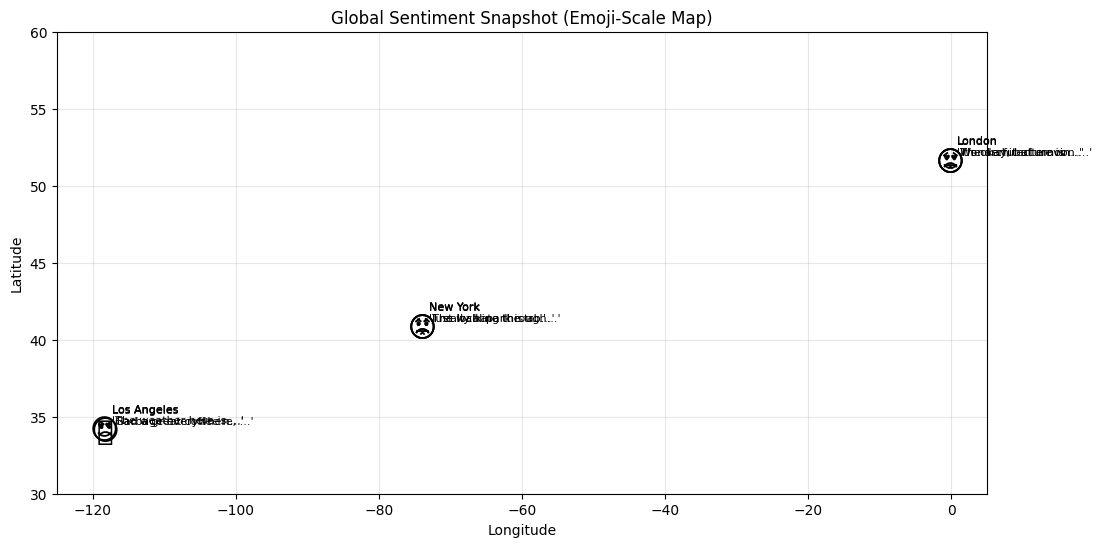

In [10]:
def map_sentiment(data):
    model.eval()
    plt.figure(figsize=(12, 6))
    
    for text, label, lat, lon, city in data:
        tokens = tokenize(text)
        indices = [vocab.get(t, 1) for t in tokens][:MAX_LEN]
        indices += [0] * (MAX_LEN - len(indices))
        
        with torch.no_grad():
            pred = model(torch.tensor([indices]))
            pred_class = torch.argmax(pred, 1).item()
            emoji = sentiment_map[pred_class]
        
        # Plotting the emoji at the specific coordinate
        plt.text(lon, lat, emoji, fontsize=20, ha='center', va='center')
        plt.annotate(f"{city}\n'{text[:20]}...'", (lon, lat), xytext=(5, 5), textcoords='offset points', fontsize=8)

    plt.xlim(-125, 5)
    plt.ylim(30, 60)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Global Sentiment Snapshot (Emoji-Scale Map)")
    plt.grid(True, alpha=0.3)
    plt.show()

map_sentiment(raw_data)

## 6. Real-time Inference
Input a phrase and see which emoji the model assigns!

In [11]:
def predict_emoji(phrase):
    model.eval()
    indices = [vocab.get(t, 1) for t in tokenize(phrase)][:MAX_LEN]
    indices += [0] * (MAX_LEN - len(indices))
    pred = model(torch.tensor([indices]))
    pred_class = torch.argmax(pred, 1).item()
    print(f"Phrase: '{phrase}' -> {sentiment_map[pred_class]}")

predict_emoji("I love this amazing sunny morning in London")
predict_emoji("Total disaster area, truly horrible")

Phrase: 'I love this amazing sunny morning in London' -> 🙂
Phrase: 'Total disaster area, truly horrible' -> 😐
